In [14]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import numpy as np
import json
import os

TEXTWIDTH = 4.80

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['STIXGeneral', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset':  'stix',
    'font.size':          8,
    'axes.titlesize':     9,
    'axes.titleweight':  'bold',
    'axes.labelsize':     8.5,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    6.5,
    'legend.handlelength': 1.8,
    'legend.columnspacing': 0.8,
    'legend.handletextpad': 0.4,
    'figure.titlesize':   9,
    'axes.linewidth':     0.5,
    'xtick.major.width':  0.4,
    'ytick.major.width':  0.4,
    'xtick.major.size':   2.5,
    'ytick.major.size':   2.5,
    'grid.linewidth':     0.3,
    'grid.alpha':         0.30,
    'grid.linestyle':     '--',
    'lines.linewidth':    1.0,
    'lines.markersize':   3.0,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.03,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

C = dict(
    blue      = '#0072B2',
    orange    = '#E69F00',
    sky       = '#56B4E9',
    green     = '#009E73',
    vermillion= '#D55E00',
    pink      = '#CC79A7',
    gray      = '#666666',
    black     = '#000000',
)

SAVE = '../images'
os.makedirs(SAVE, exist_ok=True)


def load_log(fn):
    with open(f'../logs/{fn}') as f:
        rows = [json.loads(l) for l in f]
    ep = sorted({r['Epoch'] for r in rows})
    tr = [r['Train loss'] for r in rows if 'Train loss' in r]
    te = [r['Test loss']  for r in rows if 'Test loss'  in r]
    return np.array(ep), np.array(tr), np.array(te)


def plot_curves(ax, models, scale=1.0, markevery=5):
    for fname, label, color, marker in models:
        ep, tr, te = load_log(fname)
        tr, te = scale * tr, scale * te
        ax.plot(ep, tr, color=color, marker=marker, markevery=markevery,
                markersize=2.5, linewidth=0.65, alpha=0.40)
        ax.plot(ep, te, color=color, linestyle='--', linewidth=1.15)
    handles = [Line2D([0], [0], color=c, lw=1.15) for _, _, c, _ in models]
    labels  = [lb for _, lb, _, _ in models]
    return handles, labels

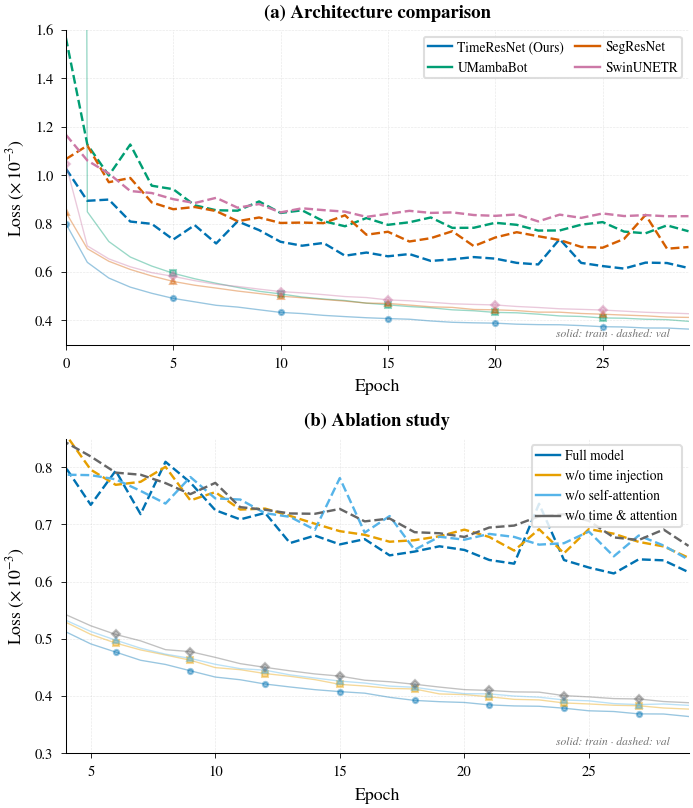

In [ ]:
# Flow Matching: Architecture comparison + Ablation study
SCALE = 1e3

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(TEXTWIDTH, TEXTWIDTH * 1.16), sharey=False)

# (a) Architecture comparison
arch = [
    ('run_lemon-shape-1_model.json',     'TimeResNet (Ours)', C['blue'],       'o'),
    ('run_volcanic-dragon-2_model.json',  'UMambaBot',         C['green'],      's'),
    ('run_vivid-lion-3_model.json',       'SegResNet',         C['vermillion'], '^'),
    ('run_royal-breeze-5_model.json',     'SwinUNETR',         C['pink'],       'D'),
]
h, l = plot_curves(ax1, arch, scale=SCALE, markevery=5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel(r'Loss ($\times\,10^{-3}$)')
ax1.set_title('(a) Architecture comparison')
ax1.legend(h, l, ncol=2, loc='upper right',
           framealpha=0.85, edgecolor='0.85', borderpad=0.3)
ax1.set_xlim(0, 29)
ax1.set_ylim(0.3, 1.6)
ax1.grid(True)
ax1.text(0.97, 0.02, 'solid: train \u00b7 dashed: val',
         transform=ax1.transAxes, fontsize=5.5, ha='right', va='bottom',
         style='italic', color='0.45')

# (b) Ablation study
abl = [
    ('run_lemon-shape-1_model.json',         'Full model',            C['blue'],   'o'),
    ('run_still-sky-6_model.json',           'w/o time injection',    C['orange'], 's'),
    ('run_misunderstood-cloud-7_model.json', 'w/o self-attention',    C['sky'],    '^'),
    ('run_polar-lion-8_model.json',          'w/o time & attention',  C['gray'],   'D'),
]
h, l = plot_curves(ax2, abl, scale=SCALE, markevery=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel(r'Loss ($\times\,10^{-3}$)')
ax2.set_title('(b) Ablation study')
ax2.legend(h, l, ncol=1, loc='upper right',
           framealpha=0.85, edgecolor='0.85', borderpad=0.3)
ax2.set_xlim(4, 29)
ax2.set_ylim(0.3, 0.85)
ax2.grid(True)
ax2.text(0.97, 0.02, 'solid: train \u00b7 dashed: val',
         transform=ax2.transAxes, fontsize=5.5, ha='right', va='bottom',
         style='italic', color='0.45')

fig.tight_layout(w_pad=1.0)
fig.savefig(f'{SAVE}/flow_loss_plot.pdf')
plt.show()

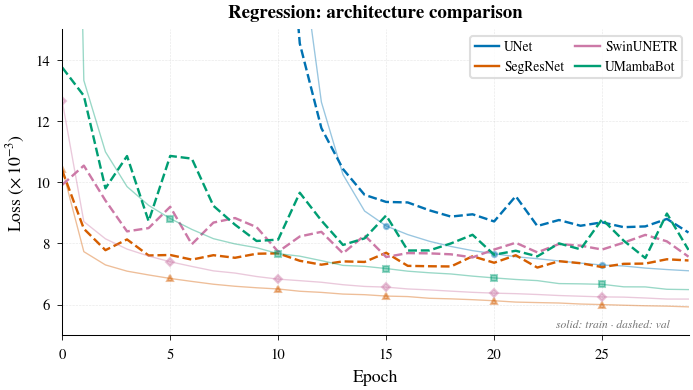

In [16]:
# Regression: Architecture comparison
SCALE_REG = 1e3

fig, ax = plt.subplots(figsize=(TEXTWIDTH, TEXTWIDTH * 0.58))

reg = [
    ('run_ancient-brook-1_model.json',  'UNet',      C['blue'],       'o'),
    ('run_sandy-moon-3_model.json',     'SegResNet',  C['vermillion'], '^'),
    ('run_grievous-senate-4_model.json','SwinUNETR',  C['pink'],       'D'),
    ('run_ancient-bantha-5_model.json', 'UMambaBot', C['green'],      's'),
]
h, l = plot_curves(ax, reg, scale=SCALE_REG, markevery=5)

ax.set_xlabel('Epoch')
ax.set_ylabel(r'Loss ($\times\,10^{-3}$)')
ax.set_title('Regression: architecture comparison')
ax.legend(h, l, ncol=2, loc='upper right',
          framealpha=0.85, edgecolor='0.85', borderpad=0.3)
ax.set_xlim(0, 29)
ax.set_ylim(5.0, 15.0)
ax.grid(True)
ax.text(0.97, 0.02, 'solid: train \u00b7 dashed: val',
        transform=ax.transAxes, fontsize=5.5, ha='right', va='bottom',
        style='italic', color='0.45')

fig.tight_layout()
fig.savefig(f'{SAVE}/reg_loss_plot.pdf')
plt.show()

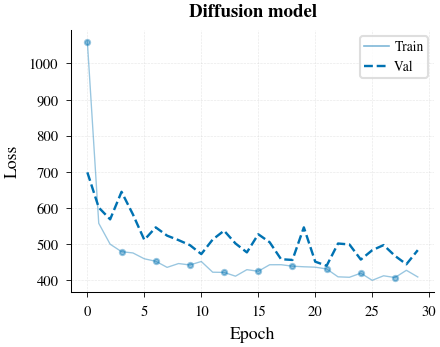

In [17]:
# Diffusion model: Training curve
fig, ax = plt.subplots(figsize=(TEXTWIDTH * 0.65, TEXTWIDTH * 0.52))

ep, tr, te = load_log('run_holographic-midichlorian-1_model.json')

ax.plot(ep, tr, color=C['blue'], marker='o', markevery=3,
        markersize=2.5, linewidth=0.65, alpha=0.40)
ax.plot(ep, te, color=C['blue'], linestyle='--', linewidth=1.15)

h = [Line2D([0], [0], color=C['blue'], linestyle='-',  lw=0.8, alpha=0.5),
     Line2D([0], [0], color=C['blue'], linestyle='--', lw=1.15)]
ax.legend(h, ['Train', 'Val'], framealpha=0.85, edgecolor='0.85', borderpad=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Diffusion model')
ax.grid(True)

fig.tight_layout()
fig.savefig(f'{SAVE}/dif_loss_plot.pdf')
plt.show()

In [11]:
# Parameter counts (from saved checkpoints)
import torch

path_ck = '../checkpoint'

all_ckpts = [
    ('Flow', 'TimeResNet (Ours)',     'run_lemon-shape-1_model_best.pth'),
    ('Flow', 'UMambaBot',             'run_volcanic-dragon-2_model_best.pth'),
    ('Flow', 'SegResNet',             'run_vivid-lion-3_model_best.pth'),
    ('Flow', 'SwinUNETR',             'run_royal-breeze-5_model_best.pth'),
    ('Flow', 'w/o time injection',    'run_still-sky-6_model_best.pth'),
    ('Flow', 'w/o self-attention',    'run_misunderstood-cloud-7_model_best.pth'),
    ('Flow', 'w/o time & attention',  'run_polar-lion-8_model_best.pth'),
    ('Reg',  'UNet',                  'run_ancient-brook-1_model_best.pth'),
    ('Reg',  'SegResNet',             'run_sandy-moon-3_model_best.pth'),
    ('Reg',  'SwinUNETR',             'run_grievous-senate-4_model_best.pth'),
    ('Reg',  'UMambaBot',             'run_ancient-bantha-5_model_best.pth'),
    ('Diff', 'DiffusionModel',        'run_holographic-midichlorian-1_model_best.pth'),
]

print(f"{'Task':<6} {'Model':<32} {'Params (M)':>10}")
print('=' * 52)
for task, name, ckfile in all_ckpts:
    ckpt = torch.load(f'{path_ck}/{ckfile}', weights_only=False, map_location='cpu')
    params = sum(v.numel() for v in ckpt['net'].values()) / 1e6
    print(f'{task:<6} {name:<32} {params:>10.1f}')
print('=' * 52)

Task   Model                            Params (M)
Flow   TimeResNet (Ours)                     124.6
Flow   UMambaBot                             240.0
Flow   SegResNet                             214.1
Flow   SwinUNETR                             120.1
Flow   w/o time injection                    108.2
Flow   w/o self-attention                    118.3
Flow   w/o time & attention                  101.9
Reg    UNet                                  104.2
Reg    SegResNet                             214.1
Reg    SwinUNETR                             120.1
Reg    UMambaBot                             240.0
Diff   DiffusionModel                        108.4
